In [1]:
import numpy as np
import pyccl as ccl
import healpy as hp
from tqdm import tqdm
from astropy import units as u
from matplotlib import pyplot as plt
import h5py


In [2]:
import sys, os
sys.path.append('/home/yshi/work/work_gravity/akra_series_local/utils/')
from gaussianfield import get_cl
sys.path.append('/home/yshi/work/work_gravity/akra_series_local/core/')
from hpplot import mollview


In [3]:
### Generate gamma1, gamma2 maps from convergence map using healpy
np.random.seed(12)
nside = 1024
lmax = int(nside*2)
nside_out = nside

from akra_full import sph_kappa2gamma

l = np.arange(lmax)
cls = get_cl(ell=l)
cls[0] = 0.0
cls[1] = 0.0
### because the spin is 2, the first two multipoles are zero
alm_kappa = hp.synalm(cls)
kappa0 = hp.alm2map(alm_kappa, nside=nside_out)
gamma10, gamma20 = sph_kappa2gamma(kappa0, nside_out, lmax=lmax)

/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:37: RuntimeWarning: divide by zero encountered in divide
  kalmsE = alm_kappa / (((ell * (ell + 1.)) / ((ell + 2.) * (ell - 1))) ** 0.5)
/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:37: RuntimeWarning: invalid value encountered in divide
  kalmsE = alm_kappa / (((ell * (ell + 1.)) / ((ell + 2.) * (ell - 1))) ** 0.5)


In [4]:
# Build the native-resolution DES Y3 mask from the effective source count.
skymap_dir = "/home/yshi/Data/desy3_data2/"
data_file = "desy3_shear_maps_sharp_nside2048_zmin0.0_zmax1.5.hdf5"
bin_idx = 0
neff_th = 2  # Minimum effective source density in arcmin^-2.
nside_data = 2048

with h5py.File(skymap_dir + data_file, "r") as f:
    grp = f[list(f.keys())[bin_idx]]
    w_sum = grp["w_sum"][:]
    w2_sum = grp["w2_sum"][:]

pixarea_arcmin2 = hp.nside2pixarea(nside_data, degrees=True) * 3600.0
Neff_pix = np.divide(w_sum**2, w2_sum, out=np.zeros_like(w_sum, dtype=float), where=w2_sum > 0)
mask_highres = Neff_pix > neff_th * pixarea_arcmin2

In [5]:
# Downgrade the binary footprint to the simulation resolution.
mask = hp.ud_grade(mask_highres.astype(float), nside_out) > 0.5
gamma1_obs = gamma10 * mask
gamma2_obs = gamma20 * mask
print(f"Observed sky fraction: {mask.mean():.6f}")

Observed sky fraction: 0.103958


## Build signal, noise, and signal-plus-noise data

For each shear component, the output has shape `(3, npix)`: index 0 is the masked signal, index 1 is noise only, and index 2 is signal plus noise.

In [6]:
# Combine catalog weights inside each output pixel; power=-2 preserves sums.
w_sum_out = hp.ud_grade(np.where(mask_highres, w_sum, 0.0), nside_out, power=-2)
w2_sum_out = hp.ud_grade(np.where(mask_highres, w2_sum, 0.0), nside_out, power=-2)
Neff_pix_out = np.divide(w_sum_out**2, w2_sum_out, out=np.zeros_like(w_sum_out, dtype=float), where=w2_sum_out > 0)

sigma_e = 0.26  # RMS of each ellipticity component.
sigma_n = np.zeros_like(Neff_pix_out)
valid_noise = mask & (Neff_pix_out > 0)
sigma_n[valid_noise] = sigma_e / np.sqrt(Neff_pix_out[valid_noise])

npix = mask.size
rng1 = np.random.default_rng(10)
rng2 = np.random.default_rng(11)
gamma1_noise = rng1.normal(size=npix) * sigma_n
gamma2_noise = rng2.normal(size=npix) * sigma_n

gamma1_data = np.stack([gamma10 * mask, gamma1_noise, gamma10 * mask + gamma1_noise])
gamma2_data = np.stack([gamma20 * mask, gamma2_noise, gamma20 * mask + gamma2_noise])
data_labels = ("without noise", "noise only", "noise + signal")

data_index = 2
gamma1_obs = gamma1_data[data_index]
gamma2_obs = gamma2_data[data_index]
print("gamma1_data shape:", gamma1_data.shape)
print("gamma2_data shape:", gamma2_data.shape)
print("Selected layer:", data_labels[data_index])
print(f"Median per-component sigma_n: {np.median(sigma_n[valid_noise]):.6e}")

gamma1_data shape: (3, 12582912)
gamma2_data shape: (3, 12582912)
Selected layer: noise + signal
Median per-component sigma_n: 3.356872e-02


## AKRA reconstructions: noise and signal plus noise

In [7]:
from akra_full_cg import KappaRec_sphere_fast

reconstruction_indices = (1, 2)  # Noise only and signal + noise.
akra_maps = np.empty((len(reconstruction_indices), npix), dtype=float)
for output_index, data_index in enumerate(reconstruction_indices):
    reconstruction = KappaRec_sphere_fast(gamma1_data[data_index], gamma2_data[data_index], mask, lmax=lmax, verbose=False, neff=Neff_pix_out)
    reconstruction.sphere_AKRA()
    akra_maps[output_index] = reconstruction.kappa_akra
    print(f"AKRA finished: {data_labels[data_index]}")

akra_noise_map = akra_maps[0]
akra_map = akra_maps[1]

### the lambda factor should be corrected by noise level.

/home/yshi/work/work_gravity/akra_series_local/core/akra_full_cg.py:231: RuntimeWarning: divide by zero encountered in divide
  factor = (((ell * (ell + 1.)) / ((ell + 2.) * (ell - 1.))) ** 0.5)


lam scaled by mean inv_noise_var:  0.9030127658827708
AKRA finished: noise only
lam scaled by mean inv_noise_var:  0.9030127658827708
AKRA finished: noise + signal


## KS reconstructions: noise and signal plus noise

In [8]:
from akra_full import sph_gamma2kappa

ks_maps = np.empty((len(reconstruction_indices), npix), dtype=float)
ks_b_maps = np.empty_like(ks_maps)
for output_index, data_index in enumerate(reconstruction_indices):
    ks_maps[output_index], ks_b_maps[output_index] = sph_gamma2kappa(gamma1_data[data_index], gamma2_data[data_index], nside, lmax=lmax, return_B=True)
    print(f"KS finished: {data_labels[data_index]}")

ks_noise_map = ks_maps[0]
ks_map = ks_maps[1]

/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:56: RuntimeWarning: divide by zero encountered in divide
  alm_E = alm_E * (((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5)
/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:56: RuntimeWarning: invalid value encountered in multiply
  alm_E = alm_E * (((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5)


KS finished: noise only
KS finished: noise + signal


## 1. Noise-subtracted power spectra

For each reconstruction, the estimated signal spectrum is $C_\ell^{S+N}-N_\ell$, where $N_\ell$ is measured from the noise-only reconstruction.

In [9]:
power_lmax = min(int(lmax), 3 * hp.get_nside(kappa0) - 1)

def masked_auto_spectrum(map_values):
    return hp.alm2cl(hp.map2alm(map_values * mask, lmax=power_lmax))

cl_true = masked_auto_spectrum(kappa0)
cl_ks_total = masked_auto_spectrum(ks_map)
nl_ks = masked_auto_spectrum(ks_noise_map)
cl_ks_signal = cl_ks_total - nl_ks
cl_akra_total = masked_auto_spectrum(akra_map)
nl_akra = masked_auto_spectrum(akra_noise_map)
cl_akra_signal = cl_akra_total - nl_akra

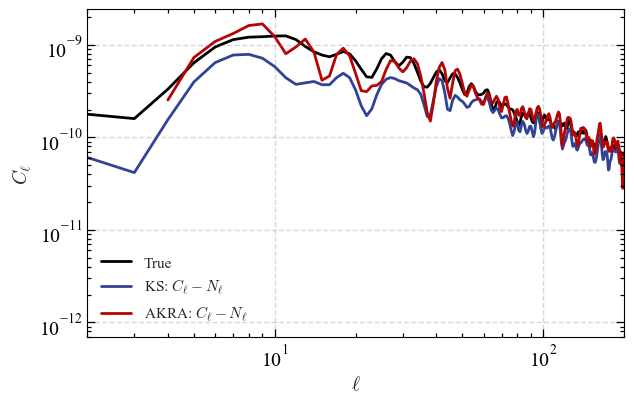

In [10]:
ell = np.arange(len(cl_true))
plt.figure(figsize=(6.5, 4.2), dpi=100)
spectra = ((cl_true, "True", "k"), (cl_ks_signal, r"KS: $C_\ell-N_\ell$", "#314396"), (cl_akra_signal, r"AKRA: $C_\ell-N_\ell$", "#B40404"))
for cl_values, label, color in spectra:
    valid = (ell >= 2) & (cl_values > 0)
    plt.loglog(ell[valid], cl_values[valid], color=color, lw=2, label=label)
plt.xlabel(r"$\ell$", fontsize=14)
plt.ylabel(r"$C_\ell$", fontsize=14)
plt.xlim(2, min(200, power_lmax))
plt.grid(ls="--", alpha=0.3, color="gray", lw=1.0)
plt.legend(framealpha=0.0, fontsize=11)
plt.tight_layout()
plt.show()



#### Here we suggest we know the noise power spectrum well! Just for demonstration, we use the noise power spectrum from the noise-only reconstruction. In practice, one may need to estimate the noise power spectrum from simulations.

## 2. NaMaster-deconvolved, noise-subtracted power spectra

The KS and AKRA signal estimates are obtained by subtracting the deconvolved noise-only bandpowers from the deconvolved signal-plus-noise bandpowers.

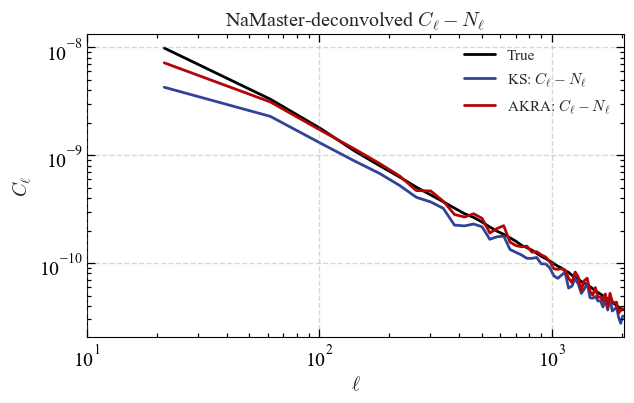

In [11]:
import pymaster as nmt

nmt_lmax = min(int(lmax), 2 * hp.get_nside(kappa0) - 1)
bin_width = 40
bins = nmt.NmtBin.from_lmax_linear(lmax=nmt_lmax, nlb=bin_width)
ell_eff = bins.get_effective_ells()

alm_true = hp.map2alm(kappa0, lmax=nmt_lmax)  # Full-sky True; no mask.
cl_true_fullsky = hp.alm2cl(alm_true)
cl_true_binned = bins.bin_cell(np.asarray([cl_true_fullsky]))[0]

binary_mask = np.asarray(mask, dtype=float)
field_ks_noise = nmt.NmtField(binary_mask, [ks_noise_map], lmax=nmt_lmax)
field_ks_total = nmt.NmtField(binary_mask, [ks_map], lmax=nmt_lmax)
field_akra_noise = nmt.NmtField(binary_mask, [akra_noise_map], lmax=nmt_lmax)
field_akra_total = nmt.NmtField(binary_mask, [akra_map], lmax=nmt_lmax)
workspace = nmt.NmtWorkspace()
workspace.compute_coupling_matrix(field_ks_total, field_ks_total, bins)

def deconvolved_auto_spectrum(field):
    return workspace.decouple_cell(nmt.compute_coupled_cell(field, field))[0]

cl_ks_deconvolved = deconvolved_auto_spectrum(field_ks_total) - deconvolved_auto_spectrum(field_ks_noise)
cl_akra_deconvolved = deconvolved_auto_spectrum(field_akra_total) - deconvolved_auto_spectrum(field_akra_noise)

plt.figure(figsize=(6.5, 4.2), dpi=100)
spectra = ((cl_true_binned, "True", "k"), (cl_ks_deconvolved, r"KS: $C_\ell-N_\ell$", "#314396"), (cl_akra_deconvolved, r"AKRA: $C_\ell-N_\ell$", "#B40404"))
for cl_values, label, color in spectra:
    valid = cl_values > 0
    plt.loglog(ell_eff[valid], cl_values[valid], color=color, lw=2, label=label)
plt.xlabel(r"$\ell$", fontsize=14)
plt.ylabel(r"$C_\ell$", fontsize=14)
plt.xlim(10, nmt_lmax)
plt.grid(ls="--", alpha=0.3, color="gray", lw=1.0)
plt.legend(framealpha=0.0, fontsize=11)
plt.title(r"NaMaster-deconvolved $C_\ell-N_\ell$")
plt.tight_layout()
plt.show()